## Step 1 - Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Step 2 - Upload the CSV (Colab)

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not in Colab - make sure the CSV is in the working directory.")

DATA_PATH = "urban_pop_percent_worldbank.csv"

Not in Colab - make sure the CSV is in the working directory.


## Step 3 - Choose Thailand's data

In [3]:
df = pd.read_csv(DATA_PATH, skiprows=4)

thailand = df[df["Country Name"] == "Thailand"]
years = [str(y) for y in range(1990, 2020)]

th = thailand[years].T.reset_index()
th.columns = ["Year", "urban_pct"]
th["Year"] = th["Year"].astype(int)
th.tail()

,Year,urban_pct
25,2015,46.952104
26,2016,47.880110
27,2017,49.231197
28,2018,54.584373
29,2019,55.926617


## Step 4 - Plot

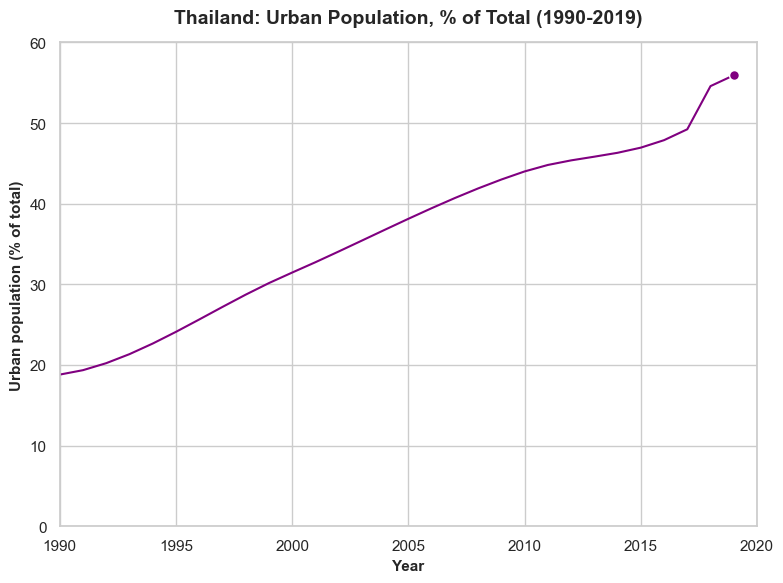

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=th, x="Year", y="urban_pct", ax=ax,
             color="purple", linewidth=1.5)

ax.set_title("Thailand: Urban Population, % of Total (1990-2019)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11, fontweight="bold")
ax.set_ylabel("Urban population (% of total)", fontsize=11, fontweight="bold")
ax.set_xlim(1990, 2020)
ax.set_ylim(0, 60)   
ax.set_xticks(sorted(set(list(range(1990, 2020, 5)) + [2020])))

first_row = th.iloc[0]
last_row = th.iloc[-1]
first_year, first_val = int(first_row["Year"]), first_row["urban_pct"]
last_year, last_val = int(last_row["Year"]), last_row["urban_pct"]
gain_pp = last_val - first_val

ax.scatter([last_year], [last_val], color="purple", s=50, zorder=5,
           edgecolor="white", linewidth=1)

plt.tight_layout()
plt.savefig("thailand_urban_population_pct.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()